In [ ]:
from google.colab import userdata
import os

token = userdata.get('GITHUB_TOKEN')
username = "petrapeacedove"
repo = "noncoding-variant-interpretation"

!git clone https://{token}@github.com/{username}/{repo}.git
%cd {repo}
!git config user.email "your_email@example.com"
!git config user.name "petrapeacedove"

Cloning into 'noncoding-variant-interpretation'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 19 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 6.94 KiB | 6.94 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/noncoding-variant-interpretation


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
pip install numpy pandas scikit-learn matplotlib seaborn cyvcf2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.3 MB/s eta 0:00:00


In [ ]:
# Download ClinVar VCF (GRCh38)
!wget -q https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz
!gunzip -k clinvar.vcf.gz   # -k keeps the .gz copy too
!ls -lh clinvar.vcf*


-rw-r--r-- 1 root root 1.8G Jul 16 04:18 clinvar.vcf
-rw-r--r-- 1 root root 184M Jul 16 04:18 clinvar.vcf.gz


In [ ]:
!pip install cyvcf2 -q


In [ ]:
from cyvcf2 import VCF

vcf = VCF('clinvar.vcf')

# Print the first 5 variant records to see what we're working with
for i, variant in enumerate(vcf):
    print(variant.CHROM, variant.POS, variant.REF, variant.ALT, variant.INFO.get('CLNSIG'), variant.INFO.get('MC'))
    if i >= 4:
        break

1 66926 AG ['A'] Uncertain_significance SO:0001627|intron_variant
1 69134 A ['G'] Likely_benign SO:0001583|missense_variant
1 69241 C ['T'] Uncertain_significance SO:0001583|missense_variant
1 69308 A ['G'] Uncertain_significance SO:0001583|missense_variant
1 69314 T ['G'] Uncertain_significance SO:0001583|missense_variant


In [ ]:
from cyvcf2 import VCF
import pandas as pd

# Non-coding consequence types we want to KEEP
NONCODING_TAGS = [
    "5_prime_UTR_variant",
    "3_prime_UTR_variant",
    "intron_variant",
    "upstream_transcript_variant",
    "downstream_transcript_variant",
    "non_coding_transcript_variant",
    "splice_region_variant",
]

# Confident labels we want to KEEP (everything else gets dropped)
CONFIDENT_LABELS = {
    "Pathogenic": 1,
    "Likely_pathogenic": 1,
    "Benign": 0,
    "Likely_benign": 0,
}

vcf = VCF('/content/clinvar.vcf')
records = []

for variant in vcf:
    mc = variant.INFO.get('MC')
    clnsig = variant.INFO.get('CLNSIG')
    geneinfo = variant.INFO.get('GENEINFO')

    if mc is None or clnsig is None:
        continue

    # Check: does MC contain at least one non-coding tag?
    is_noncoding = any(tag in mc for tag in NONCODING_TAGS)

    # Check: is CLNSIG one of our confident labels?
    label = CONFIDENT_LABELS.get(clnsig, None)

    if is_noncoding and label is not None:
        records.append({
            "chrom": variant.CHROM,
            "pos": variant.POS,
            "ref": variant.REF,
            "alt": variant.ALT[0] if variant.ALT else None,
            "gene": geneinfo,
            "mc": mc,
            "clnsig": clnsig,
            "label": label
        })

df = pd.DataFrame(records)
print(f"Total variants surviving filter: {len(df)}")
print(f"Label distribution:\n{df['label'].value_counts()}")
df.head(10)

Total variants surviving filter: 643426
Label distribution:
label
0    598724
1     44702
Name: count, dtype: int64


,chrom,pos,ref,alt,gene,mc,clnsig,label
0,1,926022,C,G,SAMD11:148398,SO:0001627|intron_variant,Likely_benign,0
1,1,926025,G,A,SAMD11:148398,SO:0001627|intron_variant,Likely_benign,0
2,1,926026,G,A,SAMD11:148398,SO:0001627|intron_variant,Likely_benign,0
3,1,926026,G,T,SAMD11:148398,SO:0001627|intron_variant,Likely_benign,0
4,1,926027,C,T,SAMD11:148398,SO:0001627|intron_variant,Likely_benign,0
5,1,926029,C,T,SAMD11:148398,SO:0001627|intron_variant,Likely_benign,0
6,1,930081,AGCCCCACCTTCCTCTCCTCCT,A,SAMD11:148398,SO:0001627|intron_variant,Likely_benign,0
7,1,930136,T,C,SAMD11:148398,SO:0001627|intron_variant,Likely_benign,0
8,1,930136,TCTC,T,SAMD11:148398,SO:0001627|intron_variant,Likely_benign,0
9,1,930139,C,T,SAMD11:148398,SO:0001627|intron_variant,Likely_benign,0


In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:
import os

sample = df.sample(500, random_state=42)

# Ensure 'data' is a directory, removing a file if it conflicts
if os.path.exists('data') and not os.path.isdir('data'):
    os.remove('data')

os.makedirs('data', exist_ok=True)

sample.to_csv('data/sample_filtered_variants.csv', index=False)

In [ ]:
!git add data/sample_filtered_variants.csv
!git commit -m "Add sample of filtered non-coding ClinVar variants (643,426 total, 500-row sample)"
!git push


[main 7844bd1] Add sample of filtered non-coding ClinVar variants (643,426 total, 500-row sample)
 2 files changed, 501 insertions(+), 1 deletion(-)
 delete mode 100644 data
 create mode 100644 data/sample_filtered_variants.csv
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 9.35 KiB | 4.68 MiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
remote: This repository moved. Please use the new location:
remote:   https://github.com/petrapeacedove/Noncoding-variant-interpretation.git
To https://github.com/petrapeacedove/noncoding-variant-interpretation.git
   eac0d8a..7844bd1  main -> main


In [ ]:
!git remote set-url origin https://{token}@github.com/petrapeacedove/Noncoding-variant-interpretation.git

In [ ]:
snv_df = df[(df['ref'].str.len() == 1) & (df['alt'].str.len() == 1)].copy()

print(f"Before SNV filter: {len(df)}")
print(f"After SNV filter: {len(snv_df)}")
print(f"Label distribution after SNV filter:\n{snv_df['label'].value_counts()}")

Before SNV filter: 643426
After SNV filter: 558288
Label distribution after SNV filter:
label
0    535913
1     22375
Name: count, dtype: int64


In [ ]:
sample = snv_df.sample(500, random_state=42)
sample.to_csv('data/sample_filtered_variants.csv', index=False)

!git add data/sample_filtered_variants.csv
!git commit -m "Step 5: filter to SNVs only (558,288 variants, 24:1 imbalance)"
!git push

[main 6738cae] Step 5: filter to SNVs only (558,288 variants, 24:1 imbalance)
 1 file changed, 501 insertions(+), 501 deletions(-)
 rewrite data/sample_filtered_variants.csv (89%)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 9.17 KiB | 4.59 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/petrapeacedove/Noncoding-variant-interpretation.git
   7844bd1..6738cae  main -> main


In [ ]:
!pip install pyBigWig -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.0/187.0 kB 4.1 MB/s eta 0:00:00


In [ ]:
# 100-way vertebrate phyloP scores, hg38
!wget -q https://hgdownload.soe.ucsc.edu/goldenPath/hg38/phyloP100way/hg38.phyloP100way.bw -O phyloP.bw
!ls -lh phyloP.bw

-rw-r--r-- 1 root root 9.2G May  8  2015 phyloP.bw


In [ ]:
import pyBigWig

bw = pyBigWig.open("phyloP.bw")

def get_phylop(chrom, pos):
    """pyBigWig uses 0-based half-open coordinates; VCF pos is 1-based."""
    try:
        chrom_name = f"chr{chrom}"  # UCSC format needs 'chr' prefix
        value = bw.values(chrom_name, pos - 1, pos)[0]
        return value
    except:
        return None

# Quick test on a handful of variants
snv_df['phyloP'] = snv_df.head(20).apply(lambda row: get_phylop(row['chrom'], row['pos']), axis=1)
snv_df[['chrom', 'pos', 'label', 'phyloP']].head(20)

,chrom,pos,label,phyloP
0,1,926022,0,-0.597
1,1,926025,0,-0.454
2,1,926026,0,1.165
3,1,926026,0,1.165
4,1,926027,0,-0.581
5,1,926029,0,-0.653
7,1,930136,0,-0.187
9,1,930139,0,-2.245
10,1,930148,0,0.384
11,1,930343,0,-0.012


In [ ]:
!wget -q https://hgdownload.soe.ucsc.edu/goldenPath/hg38/phastCons100way/hg38.phastCons100way.bw -O phastCons.bw
!ls -lh phastCons.bw

-rw-r--r-- 1 root root 5.5G May  8  2015 phastCons.bw


In [ ]:
!pip install tqdm -q
from tqdm import tqdm
tqdm.pandas()

bw_phastcons = pyBigWig.open("phastCons.bw")

def get_phastcons(chrom, pos):
    try:
        chrom_name = f"chr{chrom}"
        value = bw_phastcons.values(chrom_name, pos - 1, pos)[0]
        return value
    except:
        return None

# Full run on all 558,288 SNVs — this will take several minutes, progress bar will show status
snv_df['phyloP'] = snv_df.progress_apply(lambda row: get_phylop(row['chrom'], row['pos']), axis=1)
snv_df['phastCons'] = snv_df.progress_apply(lambda row: get_phastcons(row['chrom'], row['pos']), axis=1)

100%|██████████| 558288/558288 [00:37<00:00, 14721.92it/s]


In [ ]:
print(snv_df[['phyloP', 'phastCons']].isna().sum())
snv_df[['chrom','pos','label','phyloP','phastCons']].sample(10)

phyloP       35
phastCons    35
dtype: int64


,chrom,pos,label,phyloP,phastCons
213865,6,38906143,0,0.551,0.005
579589,19,54149769,0,-1.901,0.000
9198,1,21836660,0,0.032,0.000
532404,17,75830020,0,-0.078,0.000
268006,8,19965295,0,0.578,0.000
10474,1,24354218,0,-1.715,0.000
210889,6,32828906,0,1.945,0.015
228754,6,129291736,0,-0.030,0.000
392279,12,32737617,0,-1.238,0.000
577001,19,49861891,0,-1.622,0.000


In [ ]:
snv_df = snv_df.dropna(subset=['phyloP', 'phastCons']).reset_index(drop=True)
print(f"Final dataset size: {len(snv_df)}")
print(snv_df['label'].value_counts())

Final dataset size: 558253
label
0    535879
1     22374
Name: count, dtype: int64


In [ ]:
# Save full dataset locally in Colab (not to GitHub - too big)
snv_df.to_csv('snv_with_conservation.csv', index=False)

# Save a proper sample for GitHub
sample = snv_df.sample(500, random_state=42)
sample.to_csv('data/sample_filtered_variants.csv', index=False)

!git add data/sample_filtered_variants.csv
!git commit -m "Step 6: add phyloP + phastCons conservation scores"
!git push

[main dbe45bb] Step 6: add phyloP + phastCons conservation scores
 1 file changed, 501 insertions(+), 501 deletions(-)
 rewrite data/sample_filtered_variants.csv (97%)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 14.22 KiB | 2.03 MiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/petrapeacedove/Noncoding-variant-interpretation.git
   6738cae..dbe45bb  main -> main


In [ ]:
pathogenic = snv_df[snv_df['label'] == 1]
benign_sample = snv_df[snv_df['label'] == 0].sample(n=len(pathogenic), random_state=42)

balanced_df = pd.concat([pathogenic, benign_sample]).reset_index(drop=True)
print(f"Balanced dataset size: {len(balanced_df)}")
print(balanced_df['label'].value_counts())

Balanced dataset size: 44748
label
1    22374
0    22374
Name: count, dtype: int64


In [ ]:
!wget -q https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz -O hg38.fa.gz
!gunzip -k hg38.fa.gz
!pip install pyfaidx -q
!ls -lh hg38.fa

-rw-r--r-- 1 root root 3.1G Jan 16  2014 hg38.fa


In [ ]:
from pyfaidx import Fasta

genome = Fasta("hg38.fa")

def get_sequence_window(chrom, pos, window=10):
    """
    Extract a window of sequence centered on the variant position.
    pyfaidx uses 1-based coordinates matching VCF, convenient here.
    """
    try:
        chrom_name = f"chr{chrom}"
        start = pos - window
        end = pos + window
        seq = genome[chrom_name][start-1:end].seq.upper()
        return seq
    except:
        return None

# Test on first 5 rows of balanced_df
test = balanced_df.head(5).copy()
test['ref_window'] = test.apply(lambda row: get_sequence_window(row['chrom'], row['pos']), axis=1)
test[['chrom', 'pos', 'ref', 'alt', 'ref_window']]

,chrom,pos,ref,alt,ref_window
0,1,1043197,G,C,CTGCAGCGGAGGGGGGGCTTG
1,1,1319313,G,A,GTCTGGTGGAGGTGGACAGCC
2,1,1320529,G,A,GGGAAGCGTCGCTAGGAAGGA
3,1,1321072,C,A,GATGCAGCTTCGGCCCACGTC
4,1,1436947,C,T,ATCAGCCCCCCGAGGGGACCT


In [ ]:
!pip install pyjaspar biopython -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.3 MB/s eta 0:00:00


In [ ]:
from pyjaspar import jaspardb

jdb = jaspardb(release='JASPAR2024')

TF_SHORTLIST = ['SP1', 'CTCF', 'GATA1', 'NFKB1', 'TP53', 'MYC', 'STAT3', 'YY1', 'EGR1', 'FOXA1']

motifs = {}
for tf in TF_SHORTLIST:
    try:
        m = jdb.fetch_motifs_by_name(tf)
        if m:
            motifs[tf] = m[0]  # take first match
    except Exception as e:
        print(f"Could not fetch {tf}: {e}")

print(f"Successfully loaded {len(motifs)} motifs: {list(motifs.keys())}")

Successfully loaded 10 motifs: ['SP1', 'CTCF', 'GATA1', 'NFKB1', 'TP53', 'MYC', 'STAT3', 'YY1', 'EGR1', 'FOXA1']


In [ ]:
from Bio.Seq import Seq
import numpy as np

def score_motif_disruption(ref_window, alt_window, motifs):
    """Returns max disruption score across all TF motifs."""
    if ref_window is None or alt_window is None:
        return None

    max_disruption = 0
    for tf_name, motif in motifs.items():
        try:
            pwm = motif.pwm
            motif_len = len(motif)

            if motif_len > len(ref_window):
                continue

            best_ref_score = -np.inf
            best_alt_score = -np.inf

            for i in range(len(ref_window) - motif_len + 1):
                ref_sub = ref_window[i:i+motif_len]
                alt_sub = alt_window[i:i+motif_len]

                ref_score = sum(pwm[base][pos] for pos, base in enumerate(ref_sub) if base in pwm)
                alt_score = sum(pwm[base][pos] for pos, base in enumerate(alt_sub) if base in pwm)

                best_ref_score = max(best_ref_score, ref_score)
                best_alt_score = max(best_alt_score, alt_score)

            disruption = best_ref_score - best_alt_score
            max_disruption = max(max_disruption, disruption)
        except Exception:
            continue

    return max_disruption

def get_alt_window(ref_window, alt_base, window=10):
    """Substitute the alt allele into the center of the window."""
    if ref_window is None:
        return None
    seq_list = list(ref_window)
    seq_list[window] = alt_base
    return "".join(seq_list)

# Test on the same 5 rows
test['alt_window'] = test.apply(lambda row: get_alt_window(row['ref_window'], row['alt']), axis=1)
test['motif_disruption'] = test.apply(lambda row: score_motif_disruption(row['ref_window'], row['alt_window'], motifs), axis=1)
test[['chrom', 'pos', 'ref', 'alt', 'motif_disruption']]

,chrom,pos,ref,alt,motif_disruption
0,1,1043197,G,C,0.893796
1,1,1319313,G,A,0.995781
2,1,1320529,G,A,0.949527
3,1,1321072,C,A,0.744356
4,1,1436947,C,T,0.884277


In [ ]:
from tqdm import tqdm
tqdm.pandas()

balanced_df['ref_window'] = balanced_df.progress_apply(
    lambda row: get_sequence_window(row['chrom'], row['pos']), axis=1
)

100%|██████████| 44748/44748 [00:02<00:00, 16073.58it/s]


In [ ]:
balanced_df['alt_window'] = balanced_df.apply(
    lambda row: get_alt_window(row['ref_window'], row['alt']), axis=1
)

balanced_df['motif_disruption'] = balanced_df.progress_apply(
    lambda row: score_motif_disruption(row['ref_window'], row['alt_window'], motifs), axis=1
)

100%|██████████| 44748/44748 [03:11<00:00, 234.26it/s]


In [ ]:
print(balanced_df['motif_disruption'].isna().sum())
print(balanced_df['motif_disruption'].describe())
balanced_df[['chrom','pos','label','phyloP','phastCons','motif_disruption']].sample(10)

0
count    44748.000000
mean         0.765110
std          0.270149
min          0.000000
25%          0.641707
50%          0.891414
75%          0.971105
max          1.000000
Name: motif_disruption, dtype: float64


,chrom,pos,label,phyloP,phastCons,motif_disruption
16728,17,31226432,1,1.146,0.666,0.999166
37371,17,75960243,0,6.522,1.000,0.965399
10470,10,71319311,1,2.435,1.000,0.487440
21640,X,101403897,1,9.321,1.000,0.215604
17719,17,58216668,1,8.381,1.000,0.970053
23695,3,123291429,0,0.198,0.006,0.995781
5056,3,94003751,1,9.968,1.000,1.000000
22676,16,89548125,0,-0.443,0.000,0.995781
8735,8,43173728,1,5.910,1.000,0.985420
8550,7,156791470,1,7.289,1.000,0.723378


In [ ]:
# Save full feature-engineered dataset locally
balanced_df.to_csv('balanced_with_features.csv', index=False)

# Update GitHub sample
sample = balanced_df.sample(500, random_state=42)
sample.to_csv('data/sample_filtered_variants.csv', index=False)

!git add data/sample_filtered_variants.csv
!git commit -m "Step 7: add motif disruption scores (10 TF shortlist, balanced 44,748 dataset)"
!git push

[main 766c00b] Step 7: add motif disruption scores (10 TF shortlist, balanced 44,748 dataset)
 1 file changed, 501 insertions(+), 501 deletions(-)
 rewrite data/sample_filtered_variants.csv (98%)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 25.67 KiB | 2.85 MiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/petrapeacedove/Noncoding-variant-interpretation.git
   dbe45bb..766c00b  main -> main


In [ ]:
!wget -q http://purl.obolibrary.org/obo/hp/hpoa/genes_to_disease.txt -O genes_to_disease.txt
!head -5 genes_to_disease.txt

ncbi_gene_id	gene_symbol	association_type	disease_id	source
NCBIGene:64170	CARD9	MENDELIAN	OMIM:212050	ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/mim2gene_medgen
NCBIGene:51256	TBC1D7	MENDELIAN	OMIM:248000	ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/mim2gene_medgen
NCBIGene:28981	IFT81	MENDELIAN	OMIM:617895	ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/mim2gene_medgen
NCBIGene:8216	LZTR1	MENDELIAN	OMIM:616564	ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/mim2gene_medgen


In [ ]:
hpo = pd.read_csv('genes_to_disease.txt', sep='\t')

# Keep only Mendelian associations, get unique gene symbols
mendelian_genes = set(hpo[hpo['association_type'] == 'MENDELIAN']['gene_symbol'].unique())
print(f"Total Mendelian disease genes: {len(mendelian_genes)}")

Total Mendelian disease genes: 4875


In [ ]:

def extract_gene_symbol(geneinfo):
    if geneinfo is None:
        return None
    return geneinfo.split(':')[0]

balanced_df['gene_symbol'] = balanced_df['gene'].apply(extract_gene_symbol)
balanced_df['is_mendelian_gene'] = balanced_df['gene_symbol'].isin(mendelian_genes)

print(balanced_df['is_mendelian_gene'].value_counts())
print(f"\nOf these, label distribution within Mendelian-gene variants:")
print(balanced_df[balanced_df['is_mendelian_gene']]['label'].value_counts())

is_mendelian_gene
True     42226
False     2522
Name: count, dtype: int64

Of these, label distribution within Mendelian-gene variants:
label
1    21716
0    20510
Name: count, dtype: int64


In [ ]:
balanced_df.to_csv('balanced_with_features.csv', index=False)  # overwrite with new column

sample = balanced_df.sample(500, random_state=42)
sample.to_csv('data/sample_filtered_variants.csv', index=False)

!git add data/sample_filtered_variants.csv
!git commit -m "Step 8: cross-reference HPO Mendelian gene list (94% overlap confirmed)"
!git push

[main 1d0867b] Step 8: cross-reference HPO Mendelian gene list (94% overlap confirmed)
 1 file changed, 501 insertions(+), 501 deletions(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 4.76 KiB | 1.19 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/petrapeacedove/Noncoding-variant-interpretation.git
   766c00b..1d0867b  main -> main


In [ ]:
from sklearn.model_selection import train_test_split

feature_cols = ['phyloP', 'phastCons', 'motif_disruption', 'is_mendelian_gene']
X = balanced_df[feature_cols].copy()
X['is_mendelian_gene'] = X['is_mendelian_gene'].astype(int)  # convert True/False to 1/0
y = balanced_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train label balance:\n{y_train.value_counts(normalize=True)}")
print(f"Test label balance:\n{y_test.value_counts(normalize=True)}")

Train size: 35798, Test size: 8950
Train label balance:
label
0    0.5
1    0.5
Name: proportion, dtype: float64
Test label balance:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Feature coefficients (higher magnitude = stronger influence):")
for feat, coef in zip(feature_cols, log_reg.coef_[0]):
    print(f"  {feat}: {coef:.3f}")

Feature coefficients (higher magnitude = stronger influence):
  phyloP: 2.239
  phastCons: 0.568
  motif_disruption: 0.085
  is_mendelian_gene: 0.253


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Benign', 'Pathogenic']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

              precision    recall  f1-score   support

      Benign       0.83      0.89      0.86      4475
  Pathogenic       0.89      0.82      0.85      4475

    accuracy                           0.86      8950
   macro avg       0.86      0.86      0.86      8950
weighted avg       0.86      0.86      0.86      8950

ROC-AUC: 0.916

Confusion Matrix:
[[3998  477]
 [ 802 3673]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # tree models don't need scaling

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=['Benign', 'Pathogenic']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.3f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")

print("\nFeature importances:")
for feat, imp in sorted(zip(feature_cols, rf.feature_importances_), key=lambda x: -x[1]):
    print(f"  {feat}: {imp:.3f}")

              precision    recall  f1-score   support

      Benign       0.83      0.90      0.86      4475
  Pathogenic       0.89      0.81      0.85      4475

    accuracy                           0.86      8950
   macro avg       0.86      0.86      0.85      8950
weighted avg       0.86      0.86      0.85      8950

ROC-AUC: 0.918

Confusion Matrix:
[[4013  462]
 [ 835 3640]]

Feature importances:
  phyloP: 0.602
  phastCons: 0.350
  motif_disruption: 0.038
  is_mendelian_gene: 0.010


In [ ]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

# Build the contingency table of correct/incorrect predictions
log_reg_correct = (y_pred == y_test.values)
rf_correct = (y_pred_rf == y_test.values)

# Contingency table: [both correct, log_reg only] / [rf only, both wrong]
both_correct = np.sum(log_reg_correct & rf_correct)
logreg_only = np.sum(log_reg_correct & ~rf_correct)
rf_only = np.sum(~log_reg_correct & rf_correct)
both_wrong = np.sum(~log_reg_correct & ~rf_correct)

table = [[both_correct, logreg_only],
         [rf_only, both_wrong]]

print(f"Contingency table:\n{np.array(table)}")

result = mcnemar(table, exact=False, correction=True)
print(f"\nMcNemar's statistic: {result.statistic:.3f}")
print(f"p-value: {result.pvalue:.4f}")

Contingency table:
[[7577   94]
 [  76 1203]]

McNemar's statistic: 1.700
p-value: 0.1923


In [ ]:
import joblib
import os
import json

joblib.dump(log_reg, 'logistic_regression_model.pkl')
joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save results summary
results_summary = {
    'logistic_regression': {'accuracy': 0.86, 'roc_auc': 0.916},
    'random_forest': {'accuracy': 0.86, 'roc_auc': 0.918},
    'mcnemar_pvalue': 0.1923
}

# Ensure 'results' is a directory, removing a file if it conflicts
if os.path.exists('results') and not os.path.isdir('results'):
    os.remove('results')

# Create the 'results' directory if it doesn't exist
os.makedirs('results', exist_ok=True)

with open('results/model_comparison.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

!git add results/model_comparison.json
!git commit -m "Step 9: baseline models (LogReg AUC=0.916, RF AUC=0.918), McNemar p=0.192 (not significant)"
!git push

[main 16bc8cf] Step 9: baseline models (LogReg AUC=0.916, RF AUC=0.918), McNemar p=0.192 (not significant)
 2 files changed, 11 insertions(+), 1 deletion(-)
 delete mode 100644 results
 create mode 100644 results/model_comparison.json
Enumerating objects: 6, done.
Counting objects: 100% (6/6), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (4/4), 496 bytes | 496.00 KiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/petrapeacedove/Noncoding-variant-interpretation.git
   1d0867b..16bc8cf  main -> main


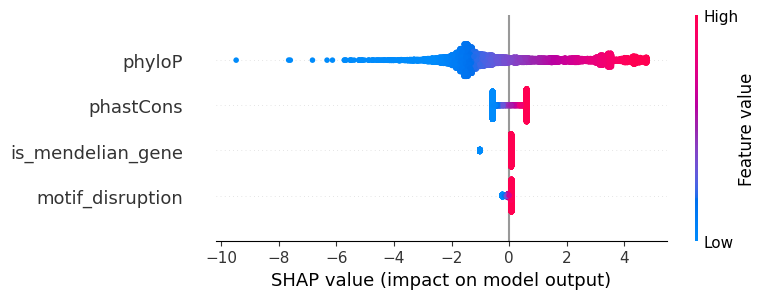

In [ ]:
!pip install shap -q
import shap

explainer = shap.LinearExplainer(log_reg, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

# Global summary — which features matter most, across all test variants
shap.summary_plot(shap_values, X_test, feature_names=feature_cols)

In [ ]:
# Pick one pathogenic and one benign test case to explain individually
import numpy as np

test_idx_pathogenic = np.where(y_test.values == 1)[0][0]
test_idx_benign = np.where(y_test.values == 0)[0][0]

for idx, label_name in [(test_idx_pathogenic, "Pathogenic example"), (test_idx_benign, "Benign example")]:
    print(f"\n--- {label_name} ---")
    print(f"Features: {dict(zip(feature_cols, X_test.iloc[idx].values))}")
    print(f"True label: {y_test.iloc[idx]}, Predicted probability (pathogenic): {log_reg.predict_proba(X_test_scaled[idx].reshape(1,-1))[0][1]:.3f}")
    for feat, shap_val in zip(feature_cols, shap_values[idx]):
        print(f"  {feat}: SHAP = {shap_val:.3f}")


--- Pathogenic example ---
Features: {'phyloP': np.float64(7.5329999923706055), 'phastCons': np.float64(1.0), 'motif_disruption': np.float64(0.9565331067390024), 'is_mendelian_gene': np.float64(0.0)}
True label: 1, Predicted probability (pathogenic): 0.960
  phyloP: SHAP = 3.230
  phastCons: SHAP = 0.609
  motif_disruption: SHAP = 0.071
  is_mendelian_gene: SHAP = -1.015

--- Benign example ---
Features: {'phyloP': np.float64(-0.5249999761581421), 'phastCons': np.float64(0.0), 'motif_disruption': np.float64(0.9580270319668656), 'is_mendelian_gene': np.float64(1.0)}
True label: 0, Predicted probability (pathogenic): 0.124
  phyloP: SHAP = -1.820
  phastCons: SHAP = -0.573
  motif_disruption: SHAP = 0.072
  is_mendelian_gene: SHAP = 0.076


In [ ]:
!git add results/
!git commit -m "Step 10: SHAP interpretability - global summary + individual case explanations"
!git push

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	balanced_with_features.csv
	genes_to_disease.txt
	hg38.fa
	hg38.fa.fai
	hg38.fa.gz
	logistic_regression_model.pkl
	phastCons.bw
	phyloP.bw
	random_forest_model.pkl
	scaler.pkl
	snv_with_conservation.csv

nothing added to commit but untracked files present (use "git add" to track)
Everything up-to-date


In [ ]:
gitignore_additions = """
# Large reference/annotation files (re-downloadable)
hg38.fa
hg38.fa.gz
hg38.fa.fai
phyloP.bw
phastCons.bw
genes_to_disease.txt
clinvar.vcf
clinvar.vcf.gz

# Large intermediate datasets (local backups exist)
balanced_with_features.csv
snv_with_conservation.csv
"""

with open('.gitignore', 'a') as f:
    f.write(gitignore_additions)

!cat .gitignore

# Raw data (too large / re-downloadable)
data/*.vcf
data/*.vcf.gz
data/*.csv
!data/sample_*.csv

# Jupyter/Colab junk
.ipynb_checkpoints/
__pycache__/
*.pyc

# OS junk
.DS_Store
Thumbs.db

# Environment
.env

# Large reference/annotation files (re-downloadable)
hg38.fa
hg38.fa.gz
hg38.fa.fai
phyloP.bw
phastCons.bw
genes_to_disease.txt
clinvar.vcf
clinvar.vcf.gz

# Large intermediate datasets (local backups exist)
balanced_with_features.csv
snv_with_conservation.csv


In [ ]:
!mkdir -p models
!mv logistic_regression_model.pkl random_forest_model.pkl scaler.pkl models/

!git add .gitignore models/
!git commit -m "Update .gitignore to exclude large reference files; add trained models"
!git push

[main 2499fe4] Update .gitignore to exclude large reference files; add trained models
 4 files changed, 14 insertions(+)
 create mode 100644 models/logistic_regression_model.pkl
 create mode 100644 models/random_forest_model.pkl
 create mode 100644 models/scaler.pkl
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (7/7), 3.84 MiB | 1.82 MiB/s, done.
Total 7 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/petrapeacedove/Noncoding-variant-interpretation.git
   16bc8cf..2499fe4  main -> main
